In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.model_selection import learning_curve
from sklearn.model_selection import RandomizedSearchCV
import joblib
import json
import os

In [4]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [5]:
df = pd.read_csv(url)

In [6]:
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [7]:
def explore_data(df):

    print("=" * 60)
    print("INFORMATIONS GÉNÉRALES")
    print("=" * 60)

    print(f"Dimensions : {df.shape}")
    print(f"Nombre de doublons : {df.duplicated().sum()}")
    print(f"Nombre de valeurs manquantes : {df.isna().sum().sum()}")
    print("\n" + "=" * 60)
    print(" TYPES DES COLONNES")
    print("=" * 60)

    print(df.dtypes)


    print("\n" + "=" * 60)
    print("VALEURS MANQUANTES")
    print("=" * 60)

    missing = df.isna().sum()
    missing = missing[missing > 0]

    if missing.empty:
        print("Aucune valeur manquante.")
    else:
        print(missing)


    categorical_cols = df.select_dtypes(include="object").columns

    print("\n" + "=" * 60)
    print("VARIABLES CATÉGORIELLES")
    print("=" * 60)

    for col in categorical_cols:
        print(f"\n {col}")
        print(f"Nombre de catégories : {df[col].nunique()}")
        print(f"Catégories : {df[col].unique()}")



In [8]:
explore_data(df)

INFORMATIONS GÉNÉRALES
Dimensions : (1067, 13)
Nombre de doublons : 0
Nombre de valeurs manquantes : 0

 TYPES DES COLONNES
MODELYEAR                     int64
MAKE                            str
MODEL                           str
VEHICLECLASS                    str
ENGINESIZE                  float64
CYLINDERS                     int64
TRANSMISSION                    str
FUELTYPE                        str
FUELCONSUMPTION_CITY        float64
FUELCONSUMPTION_HWY         float64
FUELCONSUMPTION_COMB        float64
FUELCONSUMPTION_COMB_MPG      int64
CO2EMISSIONS                  int64
dtype: object

VALEURS MANQUANTES
Aucune valeur manquante.

VARIABLES CATÉGORIELLES

 MAKE
Nombre de catégories : 39
Catégories : <ArrowStringArray>
[        'ACURA',  'ASTON MARTIN',          'AUDI',       'BENTLEY',
           'BMW',         'BUICK',      'CADILLAC',     'CHEVROLET',
      'CHRYSLER',         'DODGE',          'FIAT',          'FORD',
           'GMC',         'HONDA',       'HYUNDAI', 

C:\Users\Mariama\AppData\Local\Temp\ipykernel_14636\1567291250.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [9]:
#def clean_data()

In [10]:
data_num = df.drop(["MAKE", "MODEL", "VEHICLECLASS", "TRANSMISSION", "FUELTYPE", "MODELYEAR"], axis = 1)

In [11]:
data_num.describe()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [12]:
corr = data_num.corr()
corr

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


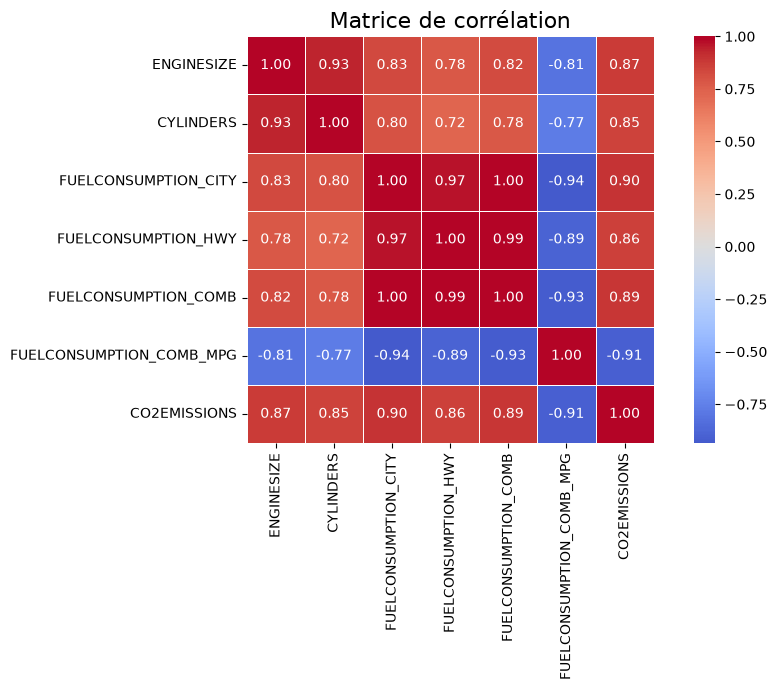

In [13]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Matrice de corrélation", fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
df = df.drop(["MODELYEAR", "CYLINDERS", "FUELCONSUMPTION_CITY", "FUELCONSUMPTION_HWY", "FUELCONSUMPTION_COMB"], axis = 1)

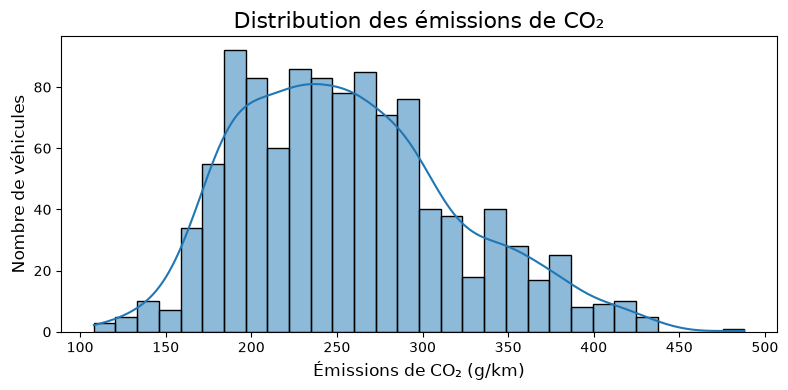

In [15]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="CO2EMISSIONS",
    bins=30,
    kde=True
)

plt.title("Distribution des émissions de CO₂", fontsize=16)
plt.xlabel("Émissions de CO₂ (g/km)", fontsize=12)
plt.ylabel("Nombre de véhicules", fontsize=12)

plt.tight_layout()
plt.show()

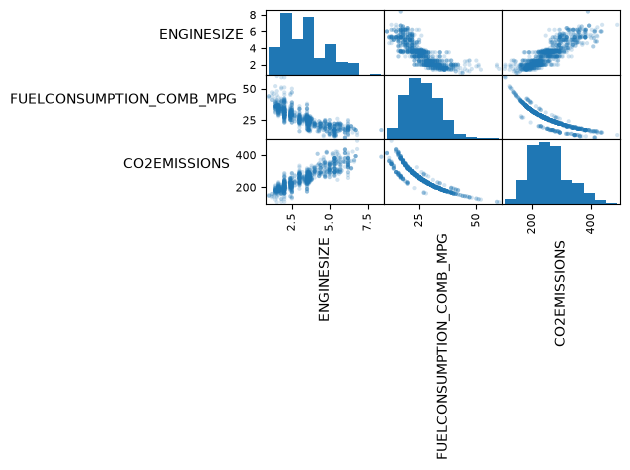

In [16]:
axes = pd.plotting.scatter_matrix(df, alpha=0.2)
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

Hypothèses :

H0 : il n'y a pas de corrélation entre les ENGINESIZE et CO2EMISSIONS VS
H1 : il existe une corrélation.

In [17]:
r, p_value = pearsonr(
    df["ENGINESIZE"],
    df["CO2EMISSIONS"]
)

print(f"Corrélation : {r:.3f}")
print(f"p-value : {p_value:.4f}")

Corrélation : 0.874
p-value : 0.0000


Puisque p-value = 0.00 < 0.05, on rejette H0, puis on accepte H1

H0 : µ_essence égale  µ_diesel VS H1 : µ_essence est différent µ_diesel

Avec μessence est l'emission moyen de CO2 de la population des véhicules d'essence et µ_diesel l'emission moyen de CO2 de la population des véhicules diesel

In [18]:
essence = df[df["FUELTYPE"] == "X"]["CO2EMISSIONS"]
diesel = df[df["FUELTYPE"] == "D"]["CO2EMISSIONS"]

stat, p_value = ttest_ind(
    essence,
    diesel,
    equal_var=False
)

print(f"Statistique : {stat:.3f}")
print(f"p-value : {p_value:.4f}")

Statistique : 1.527
p-value : 0.1365


p-value = 0.13 < 0.05, donc on rejette H0. Conclusion : les deux populations ont des moyennes différentes.

In [19]:
print("Moyenne essence :", essence.mean())
print("Moyenne diesel :", diesel.mean())

Moyenne essence : 241.09727626459144
Moyenne diesel : 227.77777777777777


Cela confirme que  l'emission moyen de CO2 de la population des véhicules d'essence  est plus élevée que  l'emission moyen de CO2 de la population des véhicules.

In [20]:
df.columns

Index(['MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'TRANSMISSION',
       'FUELTYPE', 'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='str')

In [21]:
numeric_features = [
    "ENGINESIZE",
    "FUELCONSUMPTION_COMB_MPG"

]

categorical_features = [
    "MAKE",
    "VEHICLECLASS",
    "TRANSMISSION",
    "FUELTYPE",
    "MODEL"
]

In [22]:
categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [23]:
preprocessor_per_defect = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [24]:
model_per_defect = Pipeline(
    steps=[
        ("preprocessor", preprocessor_per_defect),
        ("regressor", LinearRegression())
    ]
)

In [25]:
print("CO2EMISSIONS" in df.columns)

True


In [26]:
X = df.drop(["CO2EMISSIONS"], axis = 1)
y = df["CO2EMISSIONS"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
model_per_defect.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['MAKE','MODEL','VEHICLECLASS',...,'TRANSMISSION','FUELTYPE', 'FUELCONSUMPTION_COMB_MPG']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Th

In [29]:
y_pred = model_per_defect.predict(X_test)
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 :", r2_score(y_test, y_pred))

MSE : 179.4818708536031
R2 : 0.9565938968323899


In [30]:
numeric_transformer = Pipeline(
    steps=[

        ("scaler", StandardScaler())
    ]
)

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [32]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)



ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

In [33]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return mse, rmse, r2

In [34]:
models = {
    "Linear Regression": linear_model,
    "Ridge": ridge_model,
    "Random Forest": rf_model

}

In [35]:
for name, model in models.items():

    mse, rmse, r2 = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    print(f"\n{name}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")


Linear Regression
MSE  : 179.48
RMSE : 13.40
R²   : 0.9566

Ridge
MSE  : 130.05
RMSE : 11.40
R²   : 0.9685

Random Forest
MSE  : 27.54
RMSE : 5.25
R²   : 0.9933


In [36]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

print("Train R² :", r2_score(y_train, y_train_pred))
print("Test R²  :", r2_score(y_test, y_test_pred))

Train R² : 0.9988431332225157
Test R²  : 0.9933408103922267


In [37]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=kf,
    scoring={
        "r2": "r2",
        "mse": "neg_mean_squared_error",
        "mae": "neg_mean_absolute_error"
    },
    return_train_score=True
)

In [38]:
cv_results

{'fit_time': array([3.7419436 , 3.46053839, 4.24857378, 3.70885897, 3.81013346]),
 'score_time': array([0.04775167, 0.06919265, 0.06641722, 0.04997158, 0.0555253 ]),
 'test_r2': array([0.99334002, 0.99189779, 0.98543236, 0.99417582, 0.99640761]),
 'train_r2': array([0.99883443, 0.99895827, 0.99915504, 0.99874753, 0.99884467]),
 'test_mse': array([-27.53864398, -33.25433562, -61.28992603, -22.44330574,
        -13.24360537]),
 'train_mse': array([-4.63460496, -4.15553079, -3.33777858, -5.07396332, -4.72536283]),
 'test_mae': array([-2.82403427, -2.84638629, -3.48892019, -2.93973396, -2.60020344]),
 'train_mae': array([-1.12316921, -1.10742087, -1.06554254, -1.11443794, -1.13777127])}

In [39]:
r2_scores = cv_results["test_r2"]
mse_scores = -cv_results["test_mse"]
mae_scores = -cv_results["test_mae"]

In [40]:
print("R² par fold :", r2_scores)
print(f"R² moyen    : {r2_scores.mean():.4f}")
print(f"R² écart-type : {r2_scores.std():.4f}")

print(f"\nMSE moyen : {mse_scores.mean():.2f}")
print(f"MAE moyen : {mae_scores.mean():.2f}")

R² par fold : [0.99334002 0.99189779 0.98543236 0.99417582 0.99640761]
R² moyen    : 0.9923
R² écart-type : 0.0037

MSE moyen : 31.55
MAE moyen : 2.94


In [41]:
results_df = pd.DataFrame({
    "Itération": [f"Fold {i}" for i in range(1, 6)],
    "Entraînement": ["4 folds"] * 5,
    "Validation": [f"Fold {i}" for i in range(1, 6)],
    "R²": cv_results["test_r2"],
    "MSE": -cv_results["test_mse"],
    "MAE": -cv_results["test_mae"]
})

results_df = results_df.round(4)



In [42]:
results_df

,Itération,Entraînement,Validation,R²,MSE,MAE
0,Fold 1,4 folds,Fold 1,0.9933,27.5386,2.8240
1,Fold 2,4 folds,Fold 2,0.9919,33.2543,2.8464
2,Fold 3,4 folds,Fold 3,0.9854,61.2899,3.4889
3,Fold 4,4 folds,Fold 4,0.9942,22.4433,2.9397
4,Fold 5,4 folds,Fold 5,0.9964,13.2436,2.6002


In [43]:
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=rf_model,
    X=X,
    y=y,
    cv=kf,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Moyenne des scores sur les différents folds
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

# Écart-type
train_std = train_scores.std(axis=1)
validation_std = validation_scores.std(axis=1)



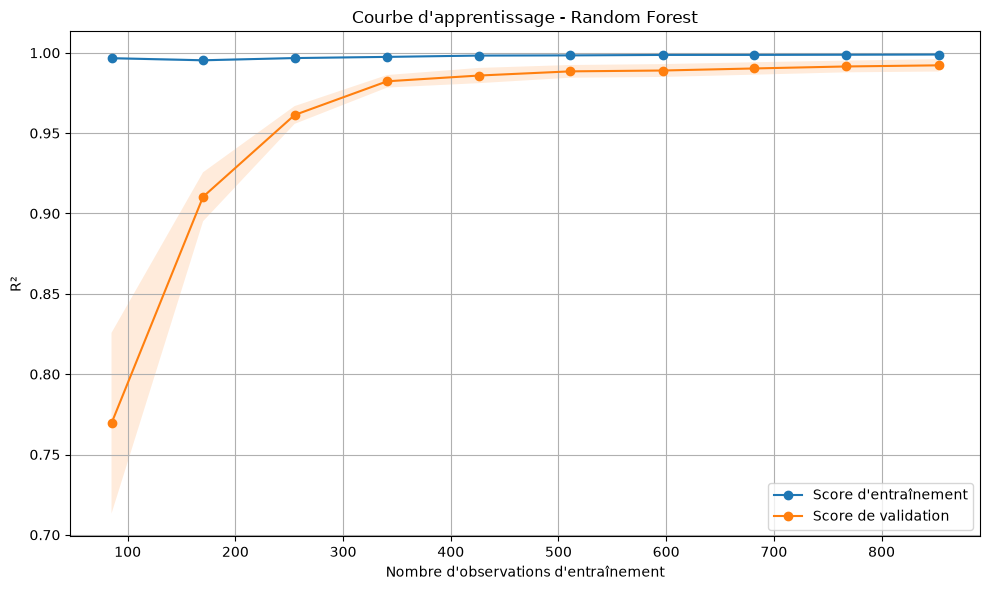

In [44]:
# Tracé
plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Score d'entraînement"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Score de validation"
)

# Zones d'incertitude
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.xlabel("Nombre d'observations d'entraînement")
plt.ylabel("R²")
plt.title("Courbe d'apprentissage - Random Forest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [45]:
#param_distributions = {
    #"regressor__n_estimators": [100, 200, 300, 500, 800],
    #"regressor__max_depth": [None, 5, 10, 15, 20, 30],
    #"regressor__min_samples_split": [2, 5, 10],
    #"regressor__min_samples_leaf": [1, 2, 4],
    #"regressor__max_features": [1.0, "sqrt", "log2"]
#}


In [46]:
#random_search = RandomizedSearchCV(
    #estimator=rf_model,
    #param_distributions=param_distributions,
    #n_iter=30,
    #scoring="r2",
    #cv=kf,
    #random_state=42,
    #n_jobs=-1,
    #verbose=1
#)

#random_search.fit(X, y)

In [47]:
#print("Meilleurs paramètres :")
#print(random_search.best_params_)

#print("\nMeilleur R² moyen :")
#print(random_search.best_score_)

In [48]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['MAKE','MODEL','VEHICLECLASS',...,'TRANSMISSION','FUELTYPE', 'FUELCONSUMPTION_COMB_MPG']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Th

In [49]:
y_pred_rf = rf_model.predict(X_test)
print("MSE :", mean_squared_error(y_test, y_pred_rf))
print("R2 :", r2_score(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

MSE : 27.535386085150574
R2 : 0.9933408103922267
RMSE : 5.247417087020106


In [50]:
prediction = rf_model.predict(X_test.iloc[:5])
prediction

array([307.70333333, 222.94333333, 293.21666667, 222.8       ,
       208.73      ])

In [51]:
joblib.dump(
    rf_model,
    "co2_random_forest_pipeline.joblib"
)

['co2_random_forest_pipeline.joblib']

In [52]:
import joblib

model = joblib.load("co2_random_forest_pipeline.joblib")

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['ENGINESIZE',
                                                   'FUELCONSUMPTION_COMB_MPG']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['MAKE', 'VEHICLECLASS',
                                                   'TRANSMISSION', 'FUELTYPE',
                                                   'MODEL'])])),
                ('regressor',
   

In [53]:
prediction_ = model.predict(X_test.iloc[:5])

print(prediction_)

[307.70333333 222.94333333 293.21666667 222.8        208.73      ]


In [54]:
columns = [
    "MAKE",
    "MODEL",
    "VEHICLECLASS",
    "TRANSMISSION",
    "FUELTYPE",
    "ENGINESIZE",
    "FUELCONSUMPTION_COMB_MPG"
]

config = (
    df[columns]
    .drop_duplicates()
    .to_dict(orient="records")
)

with open("vehicles_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

In [ ]:


#print(os.getcwd())

c:\Users\Mariama\Downloads
